Import


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/Metro_Project/data/shanghai/"

flow = pd.read_csv(
    path + "metroData_InOutFlow.csv"
)

stations = pd.read_csv(
    path + "stationInfo.csv",
    encoding="gbk"
)

weather = pd.read_csv(
    path + "shanghai_weatherHourly.csv"
)

calendar = pd.read_csv(
    path + "workday_calendar.csv"
)

In [ ]:
flow.head()

,date,timeslot,startTime,endTime,station,inFlow,outFlow,CinFlow,HBOinFlow,NHBinFlow,CoutFlow,HBOoutFlow,NHBoutFlow
0,20170501,0,60000,61000,112,29,32,9,15,5,11,13,8
1,20170501,0,60000,61000,113,142,102,40,51,51,30,41,31
2,20170501,0,60000,61000,114,66,35,17,19,30,12,10,13
3,20170501,0,60000,61000,119,23,14,6,9,8,1,3,10
4,20170501,0,60000,61000,124,17,21,2,4,11,0,9,12


In [ ]:
flow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3788892 entries, 0 to 3788891
Data columns (total 13 columns):
 #   Column       Dtype
---  ------       -----
 0   date         int64
 1    timeslot    int64
 2    startTime   int64
 3    endTime     int64
 4    station     int64
 5    inFlow      int64
 6    outFlow     int64
 7    CinFlow     int64
 8    HBOinFlow   int64
 9    NHBinFlow   int64
 10   CoutFlow    int64
 11   HBOoutFlow  int64
 12   NHBoutFlow  int64
dtypes: int64(13)
memory usage: 375.8 MB


In [ ]:
!pip install -q xgboost scikit-learn tensorflow joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import tensorflow as tf

import joblib

In [ ]:
df = flow.copy()

converting into right format


In [ ]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['date', 'timeslot', 'startTime', 'endTime', 'station', 'inFlow', 'outFlow', 'CinFlow', 'HBOinFlow', 'NHBinFlow', 'CoutFlow', 'HBOoutFlow', 'NHBoutFlow']


In [ ]:
df["date"] = pd.to_datetime(
    df["date"].astype(str),
    format="%Y%m%d"
)

In [ ]:
df["hour"] = df["startTime"] // 10000

df["minute"] = (
    (df["startTime"] // 100) % 100
)

In [ ]:
df["timestamp"] = (
    df["date"]
    + pd.to_timedelta(df["hour"], unit="h")
    + pd.to_timedelta(df["minute"], unit="m")
)

In [ ]:
print(
    df[
        ["date", "startTime", "timestamp"]
    ].head(10)
)

        date  startTime           timestamp
0 2017-05-01      60000 2017-05-01 06:00:00
1 2017-05-01      60000 2017-05-01 06:00:00
2 2017-05-01      60000 2017-05-01 06:00:00
3 2017-05-01      60000 2017-05-01 06:00:00
4 2017-05-01      60000 2017-05-01 06:00:00
5 2017-05-01      60000 2017-05-01 06:00:00
6 2017-05-01      60000 2017-05-01 06:00:00
7 2017-05-01      60000 2017-05-01 06:00:00
8 2017-05-01      60000 2017-05-01 06:00:00
9 2017-05-01      60000 2017-05-01 06:00:00


Removing incomplete days


In [ ]:
bad_dates = pd.to_datetime([
    "2017-05-04",
    "2017-05-08",
    "2017-05-09",
    "2017-06-16",
    "2017-06-27",
    "2017-06-28"
])

df = df[
    ~df["date"].isin(bad_dates)
].copy()

1St target dataset


In [ ]:
network = (
    df.groupby("timestamp")
      .agg(
          inFlow=("inFlow", "sum"),
          outFlow=("outFlow", "sum")
      )
      .reset_index()
)

In [ ]:
network = network.sort_values("timestamp")

In [ ]:
print(network.head())
print(network.shape)

            timestamp  inFlow  outFlow
0 2017-05-01 06:00:00   12533    13734
1 2017-05-01 06:10:00   14188     9958
2 2017-05-01 06:20:00   16117     8371
3 2017-05-01 06:30:00   17659     8157
4 2017-05-01 06:40:00   19563    10053
(11934, 3)


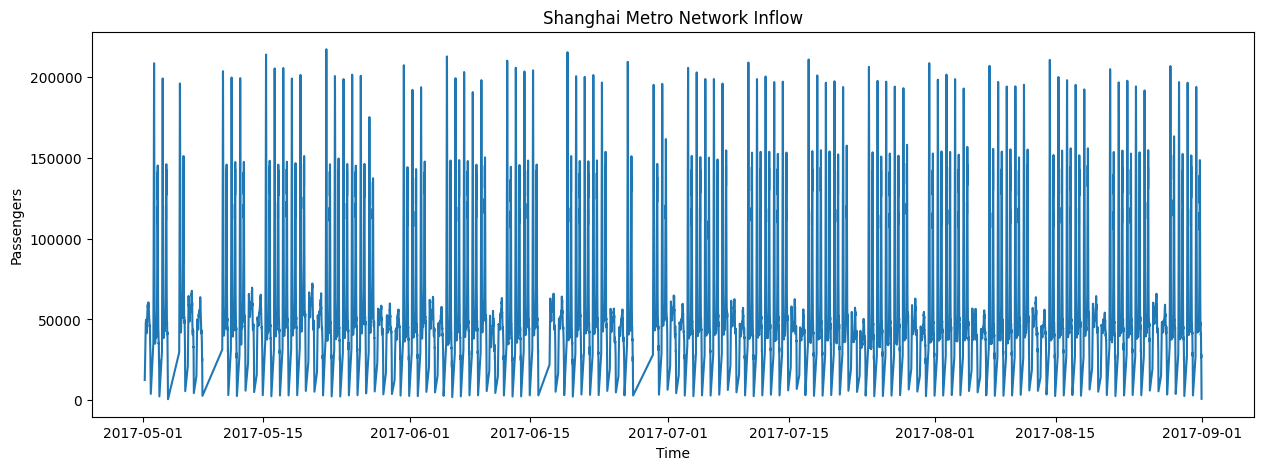

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    network["timestamp"],
    network["inFlow"]
)

plt.title("Shanghai Metro Network Inflow")
plt.xlabel("Time")
plt.ylabel("Passengers")

plt.show()

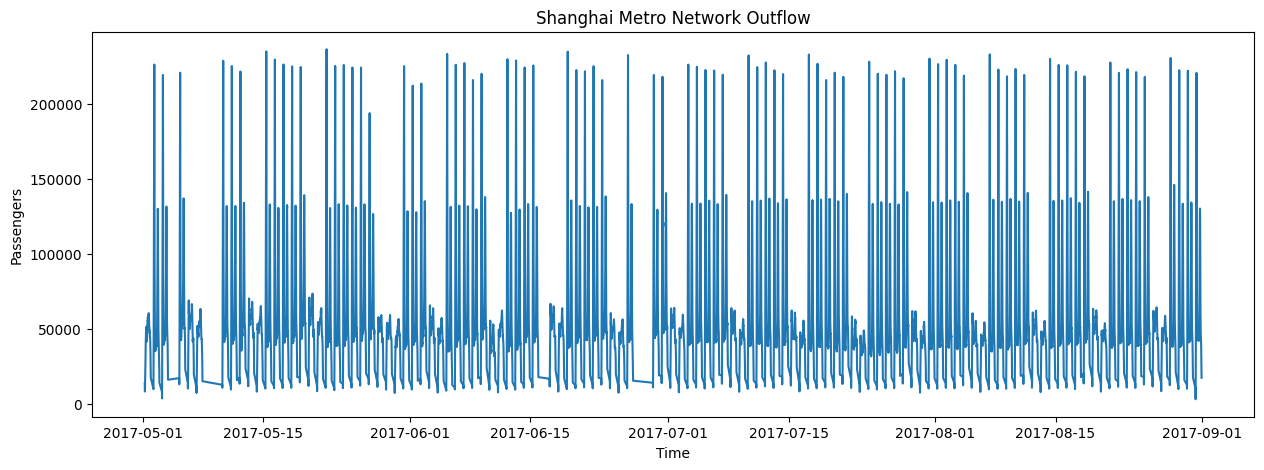

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    network["timestamp"],
    network["outFlow"]
)

plt.title("Shanghai Metro Network Outflow")
plt.xlabel("Time")
plt.ylabel("Passengers")

plt.show()

Time Features

In [ ]:
network["hour"] = network["timestamp"].dt.hour
network["minute"] = network["timestamp"].dt.minute
network["dayofweek"] = network["timestamp"].dt.dayofweek
network["dayofyear"] = network["timestamp"].dt.dayofyear

In [ ]:
network["is_weekend"] = (
    network["dayofweek"] >= 5
).astype(int)

In [ ]:
network["hour_sin"] = np.sin(
    2 * np.pi * network["hour"] / 24
)

network["hour_cos"] = np.cos(
    2 * np.pi * network["hour"] / 24
)

In [ ]:
network["dow_sin"] = np.sin(
    2 * np.pi * network["dayofweek"] / 7
)

network["dow_cos"] = np.cos(
    2 * np.pi * network["dayofweek"] / 7
)

Lagging index:
1 lag = previous 10 minutes

3 lags = previous 30 minutes

6 lags = previous 1 hour

144 lags = previous 24 hours

In [ ]:
for lag in [1, 3, 6, 12, 144]:
    network[f"in_lag_{lag}"] = (
        network["inFlow"].shift(lag)
    )

    network[f"out_lag_{lag}"] = (
        network["outFlow"].shift(lag)
    )

In [ ]:
network["in_rolling_6"] = (
    network["inFlow"]
    .shift(1)
    .rolling(6)
    .mean()
)

network["in_rolling_18"] = (
    network["inFlow"]
    .shift(1)
    .rolling(18)
    .mean()
)

network["out_rolling_6"] = (
    network["outFlow"]
    .shift(1)
    .rolling(6)
    .mean()
)

network["out_rolling_18"] = (
    network["outFlow"]
    .shift(1)
    .rolling(18)
    .mean()
)

In [ ]:
network_ml = network.dropna().copy()

In [ ]:
timestamps = network_ml["timestamp"]

train_end = timestamps.quantile(0.70)
val_end = timestamps.quantile(0.85)

train = network_ml[
    timestamps <= train_end
]

val = network_ml[
    (timestamps > train_end) &
    (timestamps <= val_end)
]

test = network_ml[
    timestamps > val_end
]

In [ ]:
print("TRAIN:", train["timestamp"].min(), train["timestamp"].max())
print("VAL:", val["timestamp"].min(), val["timestamp"].max())
print("TEST:", test["timestamp"].min(), test["timestamp"].max())

TRAIN: 2017-05-02 13:00:00 2017-07-28 11:20:00
VAL: 2017-07-28 11:30:00 2017-08-14 17:00:00
TEST: 2017-08-14 17:10:00 2017-08-31 22:50:00


MODEL 1 : Baseline

In [ ]:
y_true = test["inFlow"]

y_pred = test["in_lag_1"]

baseline_mae = mean_absolute_error(
    y_true,
    y_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 5573.742227247032
Baseline RMSE: 8721.143073971214


XG BOOST

In [ ]:
features = [
    "hour",
    "minute",
    "dayofweek",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "in_lag_1",
    "in_lag_3",
    "in_lag_6",
    "in_lag_12",
    "in_lag_144",
    "out_lag_1",
    "out_lag_3",
    "out_lag_6",
    "out_lag_12",
    "out_lag_144",
    "in_rolling_6",
    "in_rolling_18",
    "out_rolling_6",
    "out_rolling_18"
]


In [ ]:
X_train = train[features]
y_train = train["inFlow"]

X_val = val[features]
y_val = val["inFlow"]

X_test = test[features]
y_test = test["inFlow"]

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

In [ ]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 806.1292114257812
XGBoost RMSE: 1360.166579871745


Comparison baseline vs xg

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Persistence",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        xgb_rmse
    ]
})

print(results)

         Model          MAE         RMSE
0  Persistence  5573.742227  8721.143074
1      XGBoost   806.129211  1360.166580


LSTM

In [ ]:
lstm_features = [
    "inFlow",
    "outFlow",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend"
]

In [ ]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(
    train[lstm_features]
)

val_scaled = scaler.transform(
    val[lstm_features]
)

test_scaled = scaler.transform(
    test[lstm_features]
)

In [ ]:
joblib.dump(
    scaler,
    "/content/drive/MyDrive/Metro_Project/models/lstm_scaler.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Metro_Project/models/lstm_scaler.pkl'

In [ ]:
SEQ_LEN = 144

In [ ]:
def create_sequences(data, target_index=0, seq_len=144):
    X = []
    y = []

    for i in range(seq_len, len(data)):
        X.append(
            data[i-seq_len:i]
        )

        y.append(
            data[i, target_index]
        )

    return np.array(X), np.array(y)

In [ ]:
X_train_lstm, y_train_lstm = create_sequences(
    train_scaled,
    seq_len=SEQ_LEN
)

X_val_lstm, y_val_lstm = create_sequences(
    val_scaled,
    seq_len=SEQ_LEN
)

X_test_lstm, y_test_lstm = create_sequences(
    test_scaled,
    seq_len=SEQ_LEN
)

In [ ]:
print(X_train_lstm.shape)
print(y_train_lstm.shape)

(8109, 144, 7)
(8109,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16),

    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 144, 64)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_lstm,
    y_train_lstm,

    validation_data=(
        X_val_lstm,
        y_val_lstm
    ),

    epochs=50,
    batch_size=64,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 37s 230ms/step - loss: 0.1700 - mae: 0.2738 - val_loss: 0.0278 - val_mae: 0.1176
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 35s 187ms/step - loss: 0.0563 - mae: 0.1683 - val_loss: 0.0211 - val_mae: 0.1021
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 189ms/step - loss: 0.0442 - mae: 0.1487 - val_loss: 0.0207 - val_mae: 0.0996
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - loss: 0.0398 - mae: 0.1385 - val_loss: 0.0188 - val_mae: 0.0920
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - loss: 0.0341 - mae: 0.1288 - val_loss: 0.0161 - val_mae: 0.0867
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 184ms/step - loss: 0.0337 - mae: 0.1261 - val_loss: 0.0160 - val_mae: 0.0812
Epoch 7/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - loss: 0.0311 - mae: 0.1211 - val_loss: 0.0172 - val_mae: 0.0884
Epoch 8/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 177ms/step - loss: 0.0299 - mae: 0.1174 - val_loss: 0.0128 - val_mae: 0.0735
Epoch 9/50
127/127 ━━━━━━━━━━━━━

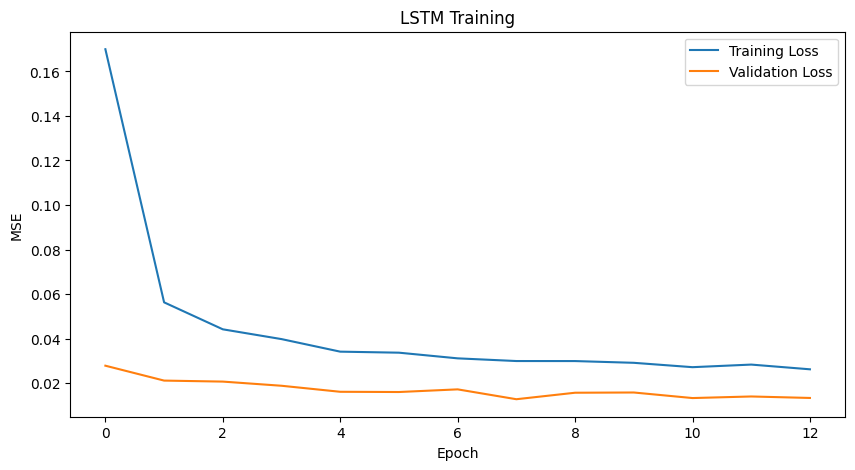

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("LSTM Training")

plt.legend()
plt.show()

In [ ]:
lstm_pred_scaled = model.predict(
    X_test_lstm
)

51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step


In [ ]:
dummy_pred = np.zeros(
    (
        len(lstm_pred_scaled),
        len(lstm_features)
    )
)

dummy_pred[:, 0] = (
    lstm_pred_scaled[:, 0]
)

lstm_pred = scaler.inverse_transform(
    dummy_pred
)[:, 0]

In [ ]:
lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual,
        lstm_pred
    )
)

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

LSTM MAE: 2823.7194560703497
LSTM RMSE: 4490.409816989208


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Persistence",
        "XGBoost",
        "LSTM"
    ],

    "MAE": [
        baseline_mae,
        xgb_mae,
        lstm_mae
    ],

    "RMSE": [
        baseline_rmse,
        xgb_rmse,
        lstm_rmse
    ]
})

print(results)

         Model          MAE         RMSE
0  Persistence  5573.742227  8721.143074
1      XGBoost   806.129211  1360.166580
2         LSTM  2823.719456  4490.409817


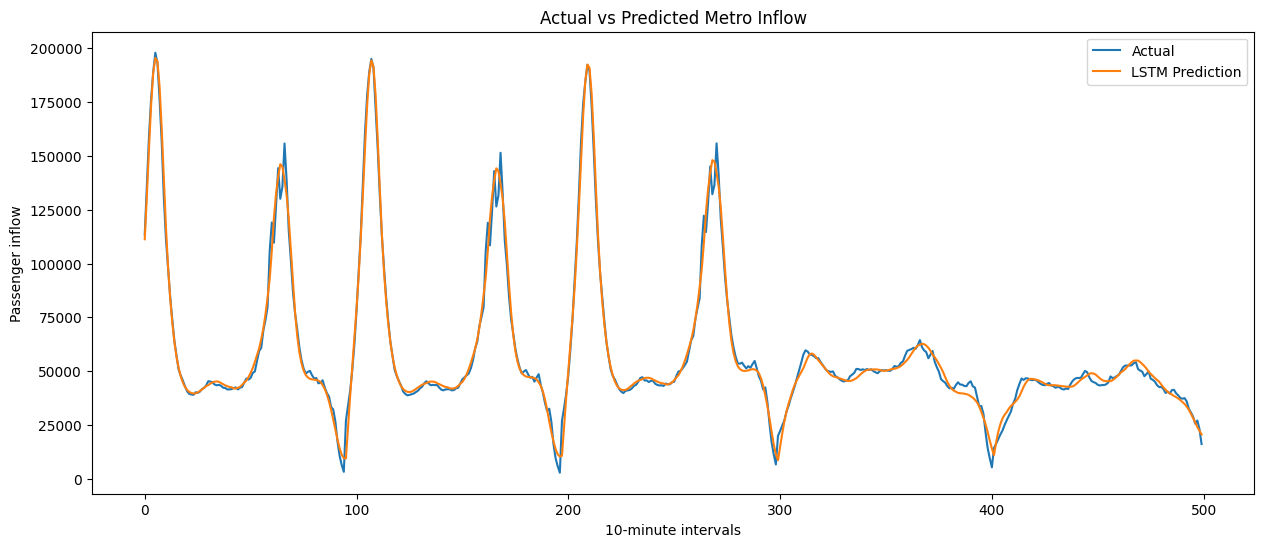

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    lstm_actual[:500],
    label="Actual"
)

plt.plot(
    lstm_pred[:500],
    label="LSTM Prediction"
)

plt.title(
    "Actual vs Predicted Metro Inflow"
)

plt.xlabel("10-minute intervals")
plt.ylabel("Passenger inflow")

plt.legend()
plt.show()